<a href="https://colab.research.google.com/github/claudinha08/My_course_SCTECH/blob/main/Desafio_Extra_SCTECH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pandas numpy matplotlib seaborn plotly

# Importanto bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.preprocessing import RobustScaler
sns.set_style('whitegrid')

In [ ]:
import plotly.express as px


#Carregando dados (importados para drive)

In [ ]:
#carregar o drive
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/datasetes/Sample_Superstore.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/datasetes/Sample_Superstore.csv'
df = pd.read_csv(path, encoding='latin-1')

print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [ ]:
df.shape

(9994, 21)

In [ ]:
#tipos
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


**Número de linha nulas: 0**

**Memória do data frame: 1.6+ MB**

In [ ]:
print(df.dtypes)
#é possivel ver as colunas

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


# Verificar dados duplicados

In [ ]:
duplicateRows = df[df.duplicated()]
print(f"número de dados duplicados: {len(duplicateRows)}")

#remover valores nulos
df.dropna(subset=[c for c in ['sales', 'profit'] if c in df.columns], inplace=True)

#converter datas
if 'Order Date' in df.columns:
   df['order_date'] = pd.to_datetime(df['Order Date'], dayfirst = False)

# converter números (vendas, lucro, desconto, quantidade)
for col in ['Sales', 'Profit', 'Discount', 'Quantitu']:
  if col in df.columns:
    df[col] = pd.to_numeric(df[col])



número de dados duplicados: 0


In [ ]:
#padronizar nome das colunas
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
print(df.columns)


Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit',
       'order_date'],
      dtype='object')


# Detecção de Outlier

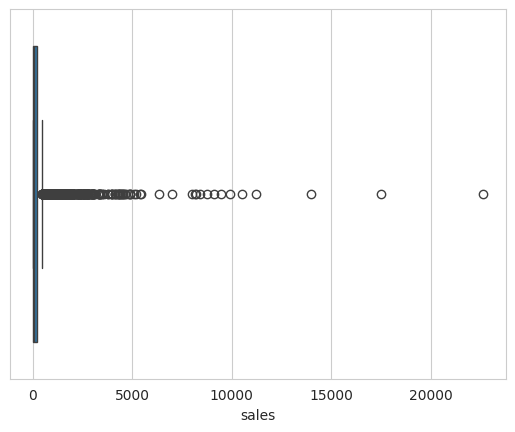

In [ ]:
#inspecionar distribuição
sns.boxplot(x=df['sales'])
plt.show()


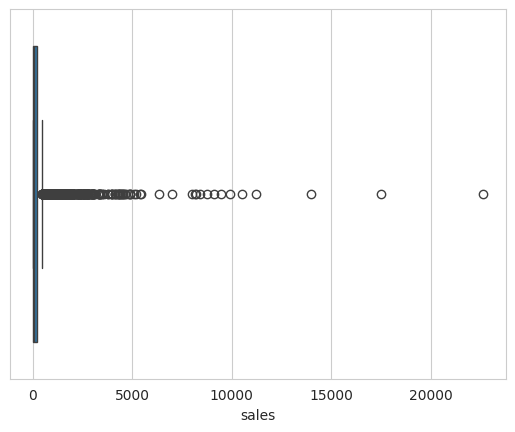

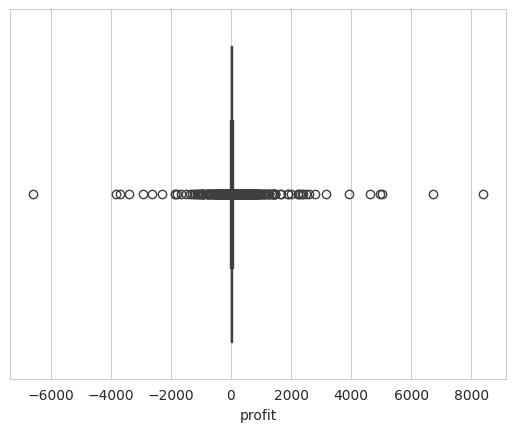

In [ ]:
#limitar extremos - tratar outliers
def winsorize_series(s, lower=0.01, upper=0.99):
  lo = s.quantile(lower)
  hi = s.quantile(upper)
  return s.clip(lo,hi)

df['sales_wins'] = winsorize_series(df['sales'])
df['profit_wins'] = winsorize_series(df['profit'])

sns.boxplot(x=df['sales'])
plt.show()
sns.boxplot(x=df['profit'])
plt.show()

In [ ]:
# Métricas derivadas
df['margin'] = df['profit'] / df['sales']

# Filtros, ordenação e agrupamento

In [ ]:
#filtro
print(df[df['profit'] >= 28.65].head()) #valores de lucro maiores que a média


    row_id        order_id order_date   ship_date       ship_mode customer_id  \
0        1  CA-2016-152156  11/8/2016  11/11/2016    Second Class    CG-12520   
1        2  CA-2016-152156  11/8/2016  11/11/2016    Second Class    CG-12520   
7        8  CA-2014-115812   6/9/2014   6/14/2014  Standard Class    BH-11710   
9       10  CA-2014-115812   6/9/2014   6/14/2014  Standard Class    BH-11710   
10      11  CA-2014-115812   6/9/2014   6/14/2014  Standard Class    BH-11710   

      customer_name   segment        country         city  ... sub-category  \
0       Claire Gute  Consumer  United States    Henderson  ...    Bookcases   
1       Claire Gute  Consumer  United States    Henderson  ...       Chairs   
7   Brosina Hoffman  Consumer  United States  Los Angeles  ...       Phones   
9   Brosina Hoffman  Consumer  United States  Los Angeles  ...   Appliances   
10  Brosina Hoffman  Consumer  United States  Los Angeles  ...       Tables   

                                      

In [ ]:
#agrupamento (GroupBy)
#vendas e lucro por categoria
vendas_lucro = df.groupby('category').agg(
    total_sales = ('sales','sum'),
    total_profit = ('profit','sum'),
    count_orders = ('order_id','nunique') if 'order_id' in df.columns else ('order_id', 'count')
    ).reset_index().sort_values('total_sales', ascending=False)

print(vendas_lucro)

          category  total_sales  total_profit  count_orders
2       Technology  836154.0330   145454.9481          1544
0        Furniture  741999.7953    18451.2728          1764
1  Office Supplies  719047.0320   122490.8008          3742


# Visualizações (matplotlib/seaborn)

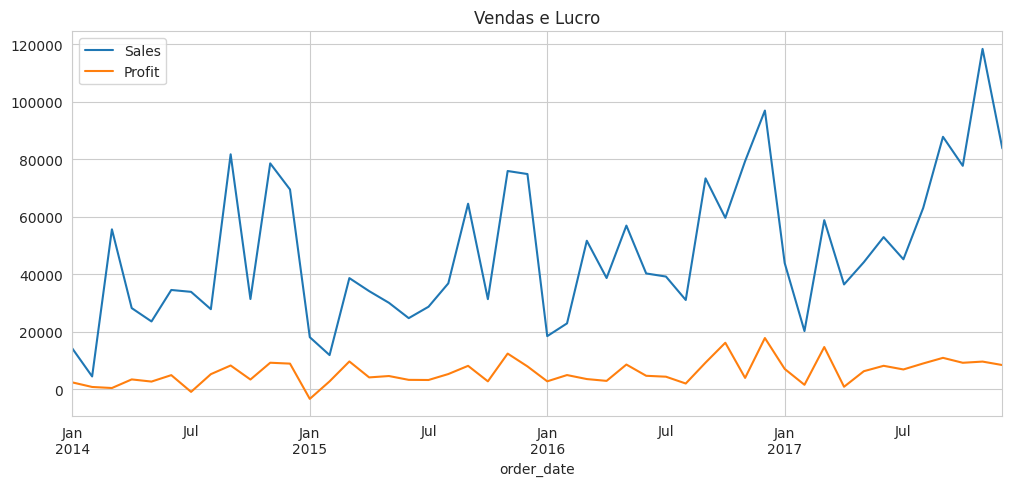

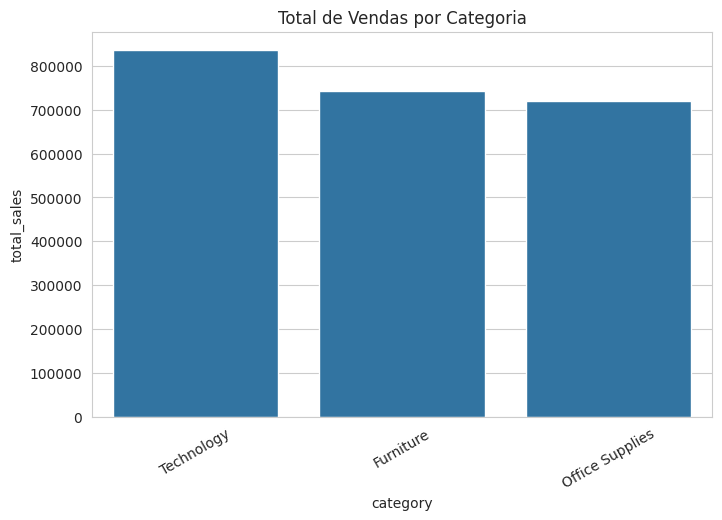

In [ ]:
#serie temporal (matplotlib)
plt.figure(figsize=(12,5))
df = df.loc[:, ~df.columns.duplicated(keep='last')] #feito com dicas, rever
monthly = df.set_index('order_date').resample('ME').sum()[['sales','profit']]
monthly['sales'].plot(label='Sales')
monthly['profit'].plot(label='Profit')
plt.legend(); plt.title('Vendas e Lucro'); plt.show()

# Barra: vendas por categoria (seaborn)
plt.figure(figsize=(8,5))
sns.barplot(data=vendas_lucro, x='category', y='total_sales')
plt.title('Total de Vendas por Categoria'); plt.xticks(rotation=30); plt.show()

# Análises Vendas, Lucro e desconto

,0
sales,229.858001
profit,28.656896


region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: profit, dtype: float64


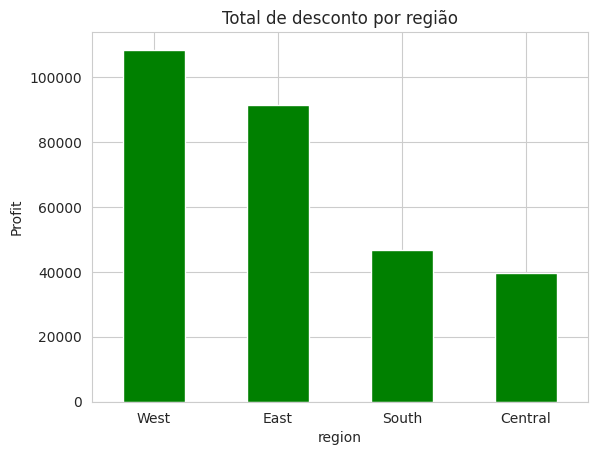

region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: sales, dtype: float64


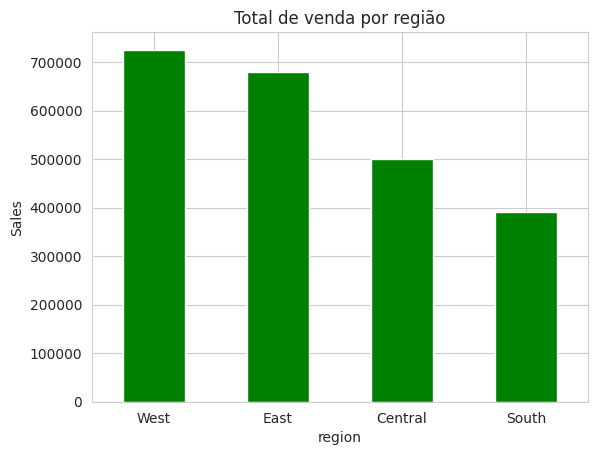

In [ ]:
df[['sales','profit']].mean()
display(df[['sales','profit']].mean())

#Análise do desconto por região
region_profit = df.groupby('region')['profit'].sum().sort_values(ascending=False)
print(region_profit)

region_profit.plot(kind='bar', color='green')
plt.title('Total de desconto por região')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.show()

#análise da venda por região
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)
print(region_sales)

region_sales.plot(kind='bar', color='green')
plt.title('Total de venda por região')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()



In [ ]:
pip freeze

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.5
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.0.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.4.20.0.58.15
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.6.11
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.39.0
bigquery-magics==0.14.0
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.4.22
